# 04 Classification Modeling — Promise Band

Predict under_half, half_to_full or late. Compare fixed models and tune Logistic Regression using validation only; test is reserved for reporting.

## 0. Setup and Load Data

Read the current processed feature table and selected_features.csv.

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from scipy.sparse import csr_matrix
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, matthews_corrcoef,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd()
if not (ROOT / "notebooks").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data/data/processed"
RANDOM_STATE = 42
TARGET = "promise_band"
BANDS = ["under_half", "half_to_full", "late"]
pd.set_option("display.max_columns", None)

df = pd.read_csv(DATA / "promise_band_feature_table.csv", parse_dates=[
    "order_purchase_timestamp", "order_delivered_customer_date",
])
selected_features = pd.read_csv(DATA / "selected_features.csv")
print("Dataset shape:", df.shape)


Dataset shape: (96470, 83)


## 1. Prepare Train / Validation / Test

Keep the existing temporal split: train 64,429; validation 12,541; test 14,471. The 5,029 excluded orders do not enter training or evaluation.

In [2]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

assert df["split"].value_counts().to_dict() == {
    "train": 64429, "val": 12541, "test": 14471, "excluded": 5029,
}
assert df["order_id"].is_unique and df[TARGET].notna().all()
assert set(df[TARGET]) == set(BANDS)
assert train_df["order_purchase_timestamp"].max() < val_df["order_purchase_timestamp"].min()
assert val_df["order_purchase_timestamp"].max() < test_df["order_purchase_timestamp"].min()
assert train_df["order_delivered_customer_date"].lt(val_df["order_purchase_timestamp"].min()).all()
assert val_df["order_delivered_customer_date"].lt(test_df["order_purchase_timestamp"].min()).all()

splits = {"Val": val_df, "Test": test_df}
split_summary = pd.DataFrame([
    {"split": name, "n": len(frame), **{
        f"{band} (%)": frame[TARGET].eq(band).mean() * 100 for band in BANDS
    }}
    for name, frame in [("Train", train_df), *splits.items()]
])
display(split_summary.round(2))
print("Excluded (not used):", df["split"].eq("excluded").sum())


Excluded (not used): 5029


,split,n,under_half (%),half_to_full (%),late (%)
0,Train,64429,55.25,36.80,7.95
1,Val,12541,70.54,24.07,5.38
2,Test,14471,60.74,32.65,6.61


## 2. Load Selected Features

The latest selected_features.csv supplies 16 features in saved rank order. Read them dynamically; do not hardcode feature names or repeat feature selection.

In [3]:
features = selected_features.sort_values("rank", kind="stable")["feature"].tolist()
assert features and len(features) == len(set(features))
assert set(features).issubset(df.columns)
assert not set(features).intersection({
    TARGET, "split", "order_id", "customer_unique_id", "seller_id",
    "actual_days", "duration_ratio", "order_purchase_timestamp",
    "order_delivered_customer_date", "order_delivered_carrier_date",
    "order_status", "order_approved_at", "review_score",
})

X_train = train_df[features]
y_train = train_df[TARGET]
print("Selected features:", len(features))
print(features)


Selected features: 16
['promised_days', 'route_prior_under_half_rate', 'distance_km', 'route_prior_mean_actual_days', 'freight_mean', 'seller_prior_mean_actual_days', 'customer_lat', 'customer_state', 'product_category', 'customer_lng', 'category_prior_mean_ratio', 'route_prior_delivered', 'seller_lat', 'seller_prior_under_half_rate', 'market_30d_late_rate', 'n_sellers']


## 3. Build Preprocessing

Median imputation for numeric features; most-frequent imputation and one-hot encoding for categorical features. Scale numeric inputs for LR only. All preprocessors fit on train.

In [4]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = [f for f in features if f not in numeric_features]

def build_preprocessor(scale=False):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore", sparse=False)),
        ]), categorical_features),
    ], remainder="drop", sparse_threshold=0)

logistic_preprocessor = build_preprocessor(scale=True)
tree_preprocessor = build_preprocessor()


## 4. Downstream Feature-Set Check: Top 10 vs Top 16

Use the saved late-AP ranking: the updated 03 chooses the shortest prefix within 0.01 of the best validation late AP, yielding 16 features. Compare only the feature set using the current plain LR parameters and identical train-fitted preprocessing. Validation only; no Test evaluation.

Choose by validation macro-F1 when its absolute gap is at least 0.01. For closer scores, consider late F1, balanced accuracy and MCC in that order. If overall performance is near-equivalent, prefer the simpler Top10 set.

In [6]:
def evaluate_classifier(model, X, y):
    pred = model.predict(X)
    report = classification_report(y, pred, labels=BANDS, output_dict=True, zero_division=0)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Macro-F1": f1_score(y, pred, labels=BANDS, average="macro", zero_division=0),
        "Weighted-F1": f1_score(y, pred, labels=BANDS, average="weighted", zero_division=0),
        "Balanced Acc": balanced_accuracy_score(y, pred),
        "MCC": matthews_corrcoef(y, pred),
        "Late Precision": report["late"]["precision"],
        "Late Recall": report["late"]["recall"],
        "Late F1": report["late"]["f1-score"],
        "report": pd.DataFrame({band: report[band] for band in BANDS}).T,
        "matrix": confusion_matrix(y, pred, labels=BANDS),
    }


In [17]:
feature_ranking = pd.read_csv(DATA / "feature_permutation_importance.csv")
ranked_features = feature_ranking.sort_values(
    ["importance_mean", "mutual_info"], ascending=False,
)["feature"].tolist()
assert features == ranked_features[:16]

feature_sets = {"Top10": ranked_features[:10], "Top16": ranked_features[:16]}
check_lr = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, class_weight=None, random_state=RANDOM_STATE)
downstream_models, downstream_results = {}, {}
downstream_rows = []
for name, columns in feature_sets.items():
    numeric = train_df[columns].select_dtypes(include="number").columns.tolist()
    categorical = [column for column in columns if column not in numeric]
    preprocessor = clone(logistic_preprocessor)
    preprocessor.transformers = [
        (kind, transformer, numeric if kind == "numeric" else categorical)
        for kind, transformer, _ in preprocessor.transformers
    ]
    model = Pipeline([("preprocessor", preprocessor), ("model", clone(check_lr))])
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(train_df[columns], train_df[TARGET])
    result = evaluate_classifier(model, val_df[columns], val_df[TARGET])
    downstream_models[name], downstream_results[name] = model, result
    downstream_rows.append({"Feature Set": name, "n_features": len(columns),
        **{key: value for key, value in result.items() if key not in ("report", "matrix")}})

downstream_comparison = pd.DataFrame(downstream_rows)
display(downstream_comparison.round(4))


,Feature Set,n_features,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
0,Top10,10,0.6637,0.4171,0.6594,0.4326,0.2541,0.2564,0.0148,0.0280
1,Top16,16,0.6833,0.4201,0.6696,0.4278,0.2527,0.4800,0.0178,0.0343


The two feature sets showed similar validation performance. However, Top16 achieved slightly higher Macro-F1 and consistently better late-class precision, recall, and F1. Therefore, the existing Top16 feature set was retained for subsequent modeling.

## 5. Baseline Models

Dummy uses the majority class; plain LR and the single tree use class_weight=None.

In [5]:
dummy_model = DummyClassifier(strategy="most_frequent")

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(
        C=1.0, penalty="l2", solver="lbfgs", max_iter=1000,
        class_weight=None, random_state=RANDOM_STATE,
    )),
])

decision_tree_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(class_weight=None, random_state=RANDOM_STATE)),
])


## 6. Baseline Results

Fit on train and evaluate the fixed baselines on validation and test. Full reports are collected in Section 9.

In [7]:
models = {
    "Dummy": dummy_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
}
for model in models.values():
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train, y_train)

results = {}
metric_rows, comparison_rows, report_rows = [], [], []
for name, model in models.items():
    comparison_row = {"Model": name}
    for split, frame in splits.items():
        result = evaluate_classifier(model, frame[features], frame[TARGET])
        results[name, split] = result
        metrics = {k: v for k, v in result.items() if k not in ("report", "matrix")}
        metric_rows.append({"Model": name, "Split": split, **metrics})
        comparison_row.update({f"{split} {k}": v for k, v in metrics.items()
                               if k not in ("Accuracy", "Weighted-F1")})
        report_rows.append(result["report"].assign(Model=name, Split=split))
    comparison_rows.append(comparison_row)

all_metrics = pd.DataFrame(metric_rows)
per_class = pd.concat(report_rows).rename_axis("Class").reset_index()

comparison = pd.DataFrame(comparison_rows)[[
    "Model", "Val Macro-F1", "Test Macro-F1", "Val Balanced Acc", "Test Balanced Acc",
    "Val MCC", "Test MCC", "Val Late Precision", "Val Late Recall", "Val Late F1",
    "Test Late Precision", "Test Late Recall", "Test Late F1",
]]
display(all_metrics.loc[all_metrics["Split"].eq("Val"),
    ["Model", "Macro-F1", "Late Precision", "Late Recall", "Late F1"]].round(4))


Model,Macro-F1,Late Precision,Late Recall,Late F1
Dummy,0.2758,0.0000,0.0000,0.0000
Logistic Regression,0.4202,0.4800,0.0178,0.0343
Decision Tree,0.3517,0.0821,0.1244,0.0989


Dummy predicts under_half for every order. Plain LR leads the fixed baselines on validation macro-F1 (0.4202), but late recall is only 1.78%; the single tree remains weaker overall.

## 7. Class Imbalance Experiment

Clone LR and the single tree, changing only class_weight from None to balanced. No resampling or other parameter changes.

In [9]:
balanced_logistic_model = clone(logistic_model).set_params(model__class_weight="balanced")
balanced_tree_model = clone(decision_tree_model).set_params(model__class_weight="balanced")

for model in [balanced_logistic_model, balanced_tree_model]:
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train, y_train)

weighting_models = {
    ("Logistic Regression", "None"): logistic_model,
    ("Logistic Regression", "Balanced"): balanced_logistic_model,
    ("Decision Tree", "None"): decision_tree_model,
    ("Decision Tree", "Balanced"): balanced_tree_model,
}
weighting_results = {}
weighting_metric_rows, weighting_report_rows, weighting_comparison_rows = [], [], []
for (name, weight), model in weighting_models.items():
    row = {"Model": name, "Class Weight": weight}
    for split, frame in splits.items():
        result = (results[name, split] if weight == "None" else
                  evaluate_classifier(model, frame[features], frame[TARGET]))
        weighting_results[name, weight, split] = result
        metrics = {k: v for k, v in result.items() if k not in ("report", "matrix")}
        weighting_metric_rows.append({"Model": name, "Class Weight": weight, "Split": split, **metrics})
        weighting_report_rows.append(result["report"].assign(Model=name, Weight=weight, Split=split))
        row.update({f"{split} {k}": v for k, v in metrics.items()
                    if k not in ("Accuracy", "Weighted-F1", "MCC")})
    weighting_comparison_rows.append(row)

weighting_metrics = pd.DataFrame(weighting_metric_rows)
weighting_per_class = pd.concat(weighting_report_rows).rename_axis("Class").reset_index()

weighting_comparison = pd.DataFrame(weighting_comparison_rows)[[
    "Model", "Class Weight", "Val Macro-F1", "Test Macro-F1", "Val Balanced Acc", "Test Balanced Acc",
    "Val Late Precision", "Val Late Recall", "Val Late F1",
    "Test Late Precision", "Test Late Recall", "Test Late F1",
]]
display(weighting_comparison[['Model', 'Class Weight', 'Val Macro-F1', 'Val Late Precision', 'Val Late Recall', 'Val Late F1']].round(4))


Model,Class Weight,Val Macro-F1,Val Late Precision,Val Late Recall,Val Late F1
Logistic Regression,None,0.4202,0.4800,0.0178,0.0343
Logistic Regression,Balanced,0.3828,0.1107,0.6459,0.1889
Decision Tree,None,0.3517,0.0821,0.1244,0.0989
Decision Tree,Balanced,0.3643,0.1018,0.1170,0.1089


Balanced LR raises late recall from 1.78% to 64.59%, but precision falls from 48.00% to 11.07% and macro-F1 from 0.4202 to 0.3828. This motivates a custom-weight trade-off. Balanced weighting improves the tree only modestly.

## 8. Advanced Models

Compare RF None, RF Balanced and HGB using the same unscaled, train-fitted preprocessing. RF uses 300 trees; its versions differ only in class_weight. HGB retains its fixed configuration without sample weighting.

In [11]:
random_forest_model = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight=None,
    )),
])

balanced_forest_model = clone(random_forest_model).set_params(model__class_weight="balanced")

hist_gradient_boosting_model = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

advanced_models = {
    ("Random Forest", "None"): random_forest_model,
    ("Random Forest", "Balanced"): balanced_forest_model,
    ("HistGradientBoosting", "None"): hist_gradient_boosting_model,
}
for model in advanced_models.values():
    model.fit(X_train, y_train)


Under the fixed configurations evaluated in this notebook, RF and the unweighted HGB did not outperform Logistic Regression, so subsequent tuning focused on LR.

## 9. Unified Model Comparison

Compare all eight fixed models using validation. The expandable report retains accuracy, weighted-F1, all remaining metrics and per-class precision/recall/F1/support for both splits. Test does not guide model selection.

In [12]:
combined_results = dict(weighting_results)
for split in splits:
    combined_results["Dummy", "None", split] = results["Dummy", split]
for (name, weight), model in advanced_models.items():
    for split, frame in splits.items():
        combined_results[name, weight, split] = evaluate_classifier(model, frame[features], frame[TARGET])

combined_model_keys = [("Dummy", "None"), *weighting_models, *advanced_models]
combined_metric_rows, combined_report_rows, combined_comparison_rows = [], [], []
for name, weight in combined_model_keys:
    row = {"Model": name, "Weight": weight}
    for split in splits:
        result = combined_results[name, weight, split]
        metrics = {k: v for k, v in result.items() if k not in ("report", "matrix")}
        combined_metric_rows.append({"Model": name, "Weight": weight, "Split": split, **metrics})
        combined_report_rows.append(result["report"].assign(Model=name, Weight=weight, Split=split))
        row.update({f"{split} {k}": v for k, v in metrics.items()
                    if k not in ("Accuracy", "Weighted-F1")})
    combined_comparison_rows.append(row)

combined_metrics = pd.DataFrame(combined_metric_rows)
combined_per_class = pd.concat(combined_report_rows).rename_axis("Class").reset_index()

combined_comparison = pd.DataFrame(combined_comparison_rows)[[
    "Model", "Weight", "Val Macro-F1", "Test Macro-F1", "Val Balanced Acc", "Test Balanced Acc",
    "Val MCC", "Test MCC", "Val Late Precision", "Val Late Recall", "Val Late F1",
    "Test Late Precision", "Test Late Recall", "Test Late F1",
]]
display(combined_comparison.round(4))

display(HTML(
    "<details><summary>Detailed fixed-model metrics and per-class reports</summary>"
    + combined_metrics.round(4).to_html()
    + combined_per_class[["Model", "Weight", "Split", "Class", "precision", "recall", "f1-score", "support"]].round(4).to_html()
    + "</details>"
))


,Model,Weight,Val Macro-F1,Test Macro-F1,Val Balanced Acc,Test Balanced Acc,Val MCC,Test MCC,Val Late Precision,Val Late Recall,Val Late F1,Test Late Precision,Test Late Recall,Test Late F1
0,Dummy,None,0.2758,0.2519,0.3333,0.3333,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Logistic Regression,None,0.4202,0.3867,0.4279,0.3976,0.2528,0.1375,0.4800,0.0178,0.0343,0.1267,0.0700,0.0902
2,Logistic Regression,Balanced,0.3828,0.1982,0.4929,0.4068,0.1797,0.0953,0.1107,0.6459,0.1889,0.0821,0.9415,0.1510
3,Decision Tree,None,0.3517,0.3303,0.3594,0.3659,0.0429,0.0391,0.0821,0.1244,0.0989,0.0865,0.2926,0.1336
4,Decision Tree,Balanced,0.3643,0.3315,0.3678,0.3436,0.0490,0.0389,0.1018,0.1170,0.1089,0.0555,0.1055,0.0727
5,Random Forest,None,0.3767,0.3470,0.3846,0.3587,0.1767,0.0600,1.0000,0.0015,0.0030,0.0678,0.0042,0.0079
6,Random Forest,Balanced,0.3867,0.3433,0.3941,0.3576,0.1975,0.0566,1.0000,0.0015,0.0030,0.0000,0.0000,0.0000
7,HistGradientBoosting,None,0.3825,0.3523,0.3871,0.3578,0.1618,0.0696,0.2045,0.0133,0.0250,0.0462,0.0418,0.0439


,Model,Weight,Split,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
0,Dummy,None,Val,0.7054,0.2758,0.5836,0.3333,0.0000,0.0000,0.0000,0.0000
1,Dummy,None,Test,0.6074,0.2519,0.4590,0.3333,0.0000,0.0000,0.0000,0.0000
2,Logistic Regression,None,Val,0.6833,0.4202,0.6696,0.4279,0.2528,0.4800,0.0178,0.0343
3,Logistic Regression,None,Test,0.5202,0.3867,0.5239,0.3976,0.1375,0.1267,0.0700,0.0902
4,Logistic Regression,Balanced,Val,0.4947,0.3828,0.5531,0.4929,0.1797,0.1107,0.6459,0.1889
5,Logistic Regression,Balanced,Test,0.2161,0.1982,0.2545,0.4068,0.0953,0.0821,0.9415,0.1510
6,Decision Tree,None,Val,0.5216,0.3517,0.5457,0.3594,0.0429,0.0821,0.1244,0.0989
7,Decision Tree,None,Test,0.3938,0.3303,0.4279,0.3659,0.0391,0.0865,0.2926,0.1336
8,Decision Tree,Balanced,Val,0.5512,0.3643,0.5643,0.3678,0.0490,0.1018,0.1170,0.1089
9,Decision Tree,Balanced,Test,0.4294,0.3315,0.4501,0.3436,0.0389,0.0555,0.1055,0.0727


## 10. Logistic Regression Tuning

Search only C and class_weight, keeping L2/lbfgs and the existing preprocessing. max_iter=4000 allows convergence. Initial C values: 0.01, 0.1, 0.5, 1, 2, 5, 10. Initial custom late weights: 1, 1.25, 1.5, 2, 2.5, 3, 4, 5, with under_half and half_to_full weights fixed at 1; weight 1 is equivalent to None. Include balanced as a reference.

Refine near the validation leaders for overall macro-F1, the business score and late F1, within the original bounds. A maximises macro-F1, with MCC/balanced accuracy as tie-breakers. B requires macro-F1 at least as high as balanced C=1, precision above that reference, and recall/F1 above plain C=1; then maximise the harmonic mean of macro-F1 and late F1. Test is not used.

In [14]:
tuning_preprocessor = clone(logistic_preprocessor).fit(X_train)
X_fit_lr = csr_matrix(tuning_preprocessor.transform(X_train))
X_val_lr = csr_matrix(tuning_preprocessor.transform(val_df[features]))
C_values = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# None is equivalent to custom late weight 1; do not fit that duplicate.
weight_values = ["None", "Balanced", 1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
tuning_records, fitted_lr, tuning_evaluations = [], {}, {}

def fit_lr_configuration(key):
    C, weight = key
    class_weight = (None if weight == "None" else "balanced" if weight == "Balanced" else
                    {"under_half": 1.0, "half_to_full": 1.0, "late": weight})
    model = clone(logistic_model.named_steps["model"]).set_params(
        C=C, class_weight=class_weight, max_iter=4000,
    )
    model.fit(X_fit_lr, y_train)
    result = evaluate_classifier(model, X_val_lr, val_df[TARGET])
    return key, model, result

def run_lr_search(C_grid, weights, stage):
    keys = [(round(float(C), 6), weight if isinstance(weight, str) else round(float(weight), 6))
            for C in C_grid for weight in weights]
    keys = list(dict.fromkeys(key for key in keys if key not in fitted_lr))
    warnings.simplefilter("error", ConvergenceWarning)
    # Independent fits; the sparse matrix preserves the existing preprocessing values.
    with ThreadPoolExecutor(max_workers=4) as executor:
        for key, model, result in executor.map(fit_lr_configuration, keys):
            fitted_lr[key], tuning_evaluations[key] = model, result
            tuning_records.append({"Stage": stage, "C": key[0], "Weight": key[1],
                "Iterations": int(model.n_iter_.max()),
                "Predicted Late Share": result["matrix"][:, 2].sum() / len(val_df),
                **{k: v for k, v in result.items() if k not in ("report", "matrix")}})

def rank_lr_candidates():
    table = pd.DataFrame(tuning_records)
    overall = table.sort_values(["Macro-F1", "MCC", "Balanced Acc"], ascending=False).iloc[0]
    plain = tuning_evaluations[1.0, "None"]
    balanced = tuning_evaluations[1.0, "Balanced"]
    table["Business Score"] = 2 * table["Macro-F1"] * table["Late F1"] / (
        table["Macro-F1"] + table["Late F1"])
    eligible = table[(table["Macro-F1"] >= balanced["Macro-F1"]) &
                     (table["Late Precision"] > balanced["Late Precision"]) &
                     (table["Late Recall"] > plain["Late Recall"]) &
                     (table["Late F1"] > plain["Late F1"])]
    if eligible.empty:
        raise ValueError("No candidate meets the reference-relative business trade-off; inspect validation results.")
    business = eligible.sort_values(["Business Score", "Macro-F1", "Late Precision"], ascending=False).iloc[0]
    late_best = table.sort_values(["Late F1", "Macro-F1"], ascending=False).iloc[0]
    return table, overall, business, late_best

run_lr_search(C_values, weight_values, "Coarse")
tuning_results, overall, business, late_best = rank_lr_candidates()


### Adaptive Refinement

Cache previously fitted configurations. Stop when a round improves macro-F1, the business score and late F1 by less than 0.002, or no new neighbours remain. The completed search contains 137 configurations (63 coarse + 38 + 36); second-round gains were 0.000519 / 0.001342 / 0.001295, indicating a local plateau.

In [15]:
refinement_history = []
round_number = 0
while True:
    round_number += 1
    before = np.array([overall["Macro-F1"], business["Business Score"], late_best["Late F1"]])
    fits_before = len(tuning_records)
    C_nodes = sorted({r["C"] for r in tuning_records})
    weight_nodes = sorted({1.0, *[float(r["Weight"]) for r in tuning_records
                                if not isinstance(r["Weight"], str)]})
    centres = {(float(r["C"]), r["Weight"]) for r in [overall, business, late_best]}
    for C, weight in sorted(centres, key=lambda x: (x[0], str(x[1]))):
        position = C_nodes.index(C)
        low, high = C_nodes[max(0, position - 1)], C_nodes[min(len(C_nodes) - 1, position + 1)]
        local_C = np.geomspace(low, high, 5)
        if isinstance(weight, str):
            local_weights = [weight]
        else:
            position = weight_nodes.index(float(weight))
            low, high = weight_nodes[max(0, position - 1)], weight_nodes[min(len(weight_nodes) - 1, position + 1)]
            local_weights = ["None" if np.isclose(w, 1.0) else round(float(w), 6)
                             for w in np.linspace(low, high, 5)]
        run_lr_search(local_C, local_weights, f"Refinement {round_number}")
    tuning_results, overall, business, late_best = rank_lr_candidates()
    gains = np.array([overall["Macro-F1"], business["Business Score"], late_best["Late F1"]]) - before
    new_fits = len(tuning_records) - fits_before
    refinement_history.append({"Round": round_number, "New Fits": new_fits,
        "Best Macro-F1": overall["Macro-F1"], "Best Business Score": business["Business Score"],
        "Best Late F1": late_best["Late F1"], "Macro-F1 Gain": gains[0],
        "Business Score Gain": gains[1], "Late F1 Gain": gains[2]})
    if new_fits == 0 or np.all(gains < 0.002):
        stop_reason = "No new neighbouring configurations." if new_fits == 0 else "Validation score gains below 0.002: local plateau."
        break

tuning_top10 = tuning_results.sort_values(["Macro-F1", "MCC"], ascending=False).head(10)
display(tuning_top10[['C', 'Weight', 'Macro-F1', 'Balanced Acc', 'MCC', 'Late Precision', 'Late Recall', 'Late F1']].round(4))


C,Weight,Macro-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
6.4842,2.375,0.4589,0.4565,0.2459,0.1918,0.1793,0.1853
7.0711,2.375,0.4587,0.4563,0.2453,0.1918,0.1793,0.1853
5.9460,2.25,0.4584,0.4538,0.2479,0.1996,0.1585,0.1767
5.9460,2.375,0.4583,0.4559,0.2455,0.1905,0.1778,0.1839
5.0000,2.25,0.4583,0.4538,0.2478,0.1993,0.1585,0.1766
5.4525,2.25,0.4583,0.4538,0.2478,0.1993,0.1585,0.1766
7.0711,2.25,0.4583,0.4537,0.2477,0.1996,0.1585,0.1767
8.4090,2.25,0.4583,0.4537,0.2477,0.1993,0.1585,0.1766
6.4842,2.25,0.4583,0.4537,0.2477,0.1993,0.1585,0.1766
5.0000,2.375,0.4582,0.4558,0.2453,0.1902,0.1778,0.1838


## 11. Final Model Selection

**Candidate A — Overall final candidate:** C=6.484198, custom late weight=2.375; validation macro-F1=0.4589. Use A for the overall three-class objective.

**Candidate B — Late-sensitive alternative:** C=0.289552, custom late weight=3.5; validation late F1=0.2229 and recall=0.3970, with more false alarms and a lower macro-F1 of 0.4433.

These roles are based on validation. Under the fixed configurations evaluated here, RF and the unweighted HGB did not surpass tuned LR. Freeze A/B, then report test once per distinct configuration; do not refit on validation or revise parameters after test.

In [16]:
candidate_rows = {"Candidate A": overall, "Candidate B": business}
candidate_models, candidate_results, test_cache = {}, {}, {}
candidate_summary_rows, candidate_report_rows = [], []
for label, row in candidate_rows.items():
    key = (float(row["C"]), row["Weight"])
    model = Pipeline([("preprocessor", tuning_preprocessor), ("model", fitted_lr[key])])
    candidate_models[label] = model
    if key not in test_cache:
        test_cache[key] = evaluate_classifier(model, test_df[features], test_df[TARGET])
    for split, result in [("Val", tuning_evaluations[key]), ("Test", test_cache[key])]:
        candidate_results[label, split] = result
        candidate_summary_rows.append({"Candidate": label, "C": row["C"], "Weight": row["Weight"],
            "Split": split, **{k: v for k, v in result.items() if k not in ("report", "matrix")}})
        candidate_report_rows.append(result["report"].assign(Candidate=label, Split=split))
candidate_summary = pd.DataFrame(candidate_summary_rows)
candidate_per_class = pd.concat(candidate_report_rows).rename_axis("Class").reset_index()
display(candidate_summary.round(4))
display(HTML(
    "<details><summary>Candidate per-class reports</summary>"
    + candidate_per_class[["Candidate", "Split", "Class", "precision", "recall", "f1-score", "support"]].round(4).to_html()
    + "</details>"
))



,Candidate,C,Weight,Split,Accuracy,Macro-F1,Weighted-F1,Balanced Acc,MCC,Late Precision,Late Recall,Late F1
0,Candidate A,6.4842,2.375,Val,0.6735,0.4589,0.6696,0.4565,0.2459,0.1918,0.1793,0.1853
1,Candidate A,6.4842,2.375,Test,0.4203,0.3583,0.4651,0.4656,0.1355,0.1187,0.6667,0.2015
2,Candidate B,0.2896,3.500,Val,0.6407,0.4433,0.6465,0.4832,0.2236,0.1549,0.3970,0.2229
3,Candidate B,0.2896,3.500,Test,0.3417,0.2875,0.3916,0.4521,0.1408,0.0965,0.8443,0.1732


,Candidate,Split,Class,precision,recall,f1-score,support
0,Candidate A,Val,under_half,0.7927,0.8119,0.8022,8847.0
1,Candidate A,Val,half_to_full,0.4008,0.3783,0.3892,3019.0
2,Candidate A,Val,late,0.1918,0.1793,0.1853,675.0
3,Candidate A,Test,under_half,0.7495,0.4908,0.5932,8789.0
4,Candidate A,Test,half_to_full,0.3385,0.2392,0.2803,4725.0
5,Candidate A,Test,late,0.1187,0.6667,0.2015,957.0
6,Candidate B,Val,under_half,0.7963,0.7874,0.7918,8847.0
7,Candidate B,Val,half_to_full,0.3883,0.2653,0.3152,3019.0
8,Candidate B,Val,late,0.1549,0.3970,0.2229,675.0
9,Candidate B,Test,under_half,0.7969,0.4228,0.5525,8789.0


### Candidate Selection Evidence

Candidate A maximises validation Macro-F1, with MCC and balanced accuracy as tie-breakers. Candidate B requires Macro-F1 no lower than the balanced C=1 reference, late precision above that reference, and late recall/F1 above the plain C=1 reference. Among eligible configurations, maximise the business score (the harmonic mean of Macro-F1 and late F1), then Macro-F1 and late precision. These rules use Validation only; Test is excluded.

In [18]:
candidate_selection = pd.DataFrame([
    {"Candidate": name,
     "Selection rule": ("Highest validation Macro-F1" if name == "Candidate A"
                        else "Best eligible business-score configuration"),
     "C": row["C"], "Late weight": row["Weight"],
     "Val Macro-F1": row["Macro-F1"], "Late P": row["Late Precision"],
     "Late R": row["Late Recall"], "Late F1": row["Late F1"],
     "Business Score": 2 * row["Macro-F1"] * row["Late F1"] / (row["Macro-F1"] + row["Late F1"])}
    for name, row in candidate_rows.items()
])
display(candidate_selection.round(4))


,Candidate,Selection rule,C,Late weight,Val Macro-F1,Late P,Late R,Late F1,Business Score
0,Candidate A,Highest validation Macro-F1,6.4842,2.375,0.4589,0.1918,0.1793,0.1853,0.2640
1,Candidate B,Best eligible business-score configuration,0.2896,3.500,0.4433,0.1549,0.3970,0.2229,0.2966


### Predicted Late Share

In [19]:
late_share_sources = {
    "Plain LR": {split: combined_results["Logistic Regression", "None", split]
                 for split in ["Val", "Test"]},
    "Balanced LR": {split: combined_results["Logistic Regression", "Balanced", split]
                    for split in ["Val", "Test"]},
    **{name: {split: candidate_results[name, split] for split in ["Val", "Test"]}
       for name in candidate_rows},
}
late_share_table = pd.DataFrame([
    {"Model": name, **{
        f"{label} Predicted Late Share (%)":
            100 * result["matrix"][:, BANDS.index("late")].sum() / result["matrix"].sum()
        for label, result in [("Validation", results["Val"]), ("Test", results["Test"])]
    }} for name, results in late_share_sources.items()
])
display(late_share_table.round(2))


,Model,Validation Predicted Late Share (%),Test Predicted Late Share (%)
0,Plain LR,0.20,3.66
1,Balanced LR,31.42,75.84
2,Candidate A,5.03,37.16
3,Candidate B,13.79,57.87


The tuned and weighted LR models predict substantially more late orders in the later test period, indicating unstable temporal generalization.

### Candidate A: Per-Class Validation vs Test

In [20]:
candidate_a_class_comparison = (
    candidate_per_class.loc[candidate_per_class["Candidate"].eq("Candidate A")]
    .pivot(index="Class", columns="Split", values=["f1-score", "recall"])
    .reindex(BANDS)[[("f1-score", "Val"), ("f1-score", "Test"),
                    ("recall", "Val"), ("recall", "Test")]]
)
candidate_a_class_comparison.columns = ["Validation F1", "Test F1", "Validation Recall", "Test Recall"]
display(candidate_a_class_comparison.round(4))


,Validation F1,Test F1,Validation Recall,Test Recall
Class,,,,
under_half,0.8022,0.5932,0.8119,0.4908
half_to_full,0.3892,0.2803,0.3783,0.2392
late,0.1853,0.2015,0.1793,0.6667


Candidate A's lower Test Macro-F1 is mainly driven by deterioration in under_half and half_to_full, while late F1 does not decrease.

## 12. Final Confusion Matrices

Candidate A/B on validation and test. Rows are actual classes; columns are predictions.

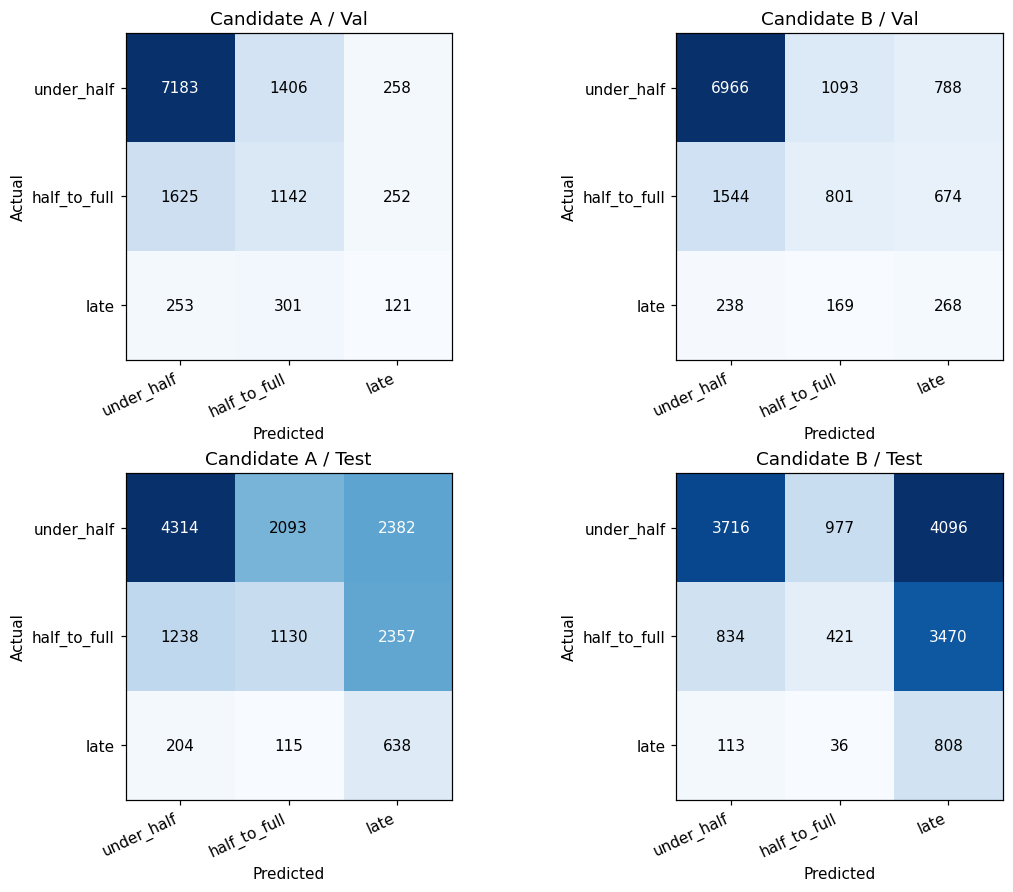

In [16]:
def plot_confusion_matrix(matrix, ax, title):
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels(BANDS, rotation=25, ha="right")
    ax.set_yticks(range(3)); ax.set_yticklabels(BANDS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > matrix.max() / 2 else "black")

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for column, label in enumerate(candidate_rows):
    for row, split in enumerate(["Val", "Test"]):
        plot_confusion_matrix(candidate_results[label, split]["matrix"], axes[row, column], f"{label} / {split}")
plt.show()


## 13. Conclusion

Tuned LR substantially exceeds Dummy on validation macro-F1 (0.4589 versus 0.2758). Candidate A is the overall final candidate; Candidate B is the late-sensitive alternative, with more false warnings. Within the explored search region, changes in class weighting had a larger practical effect than nearby changes in C.

Candidate A was the best validation-selected tuned model, while plain LR achieved the highest Test Macro-F1 among the evaluated LR variants. This indicates that the validation improvement from tuning did not fully transfer to the later test period. A/B were selected using Validation only; Test did not participate in tuning rankings or model selection. Their Test results were evaluated only after the candidates were frozen.